# Importaciones

In [30]:
from __future__ import annotations

import time
import warnings
from typing import Any

import numpy as np
import pandas as pd
import yfinance as yf

import time


from pathlib import Path
import pickle


import matplotlib.pyplot as plt


# Principales índices del mundo

El objeto `MARKET_METADATA` es un diccionario de configuración en Python que **centraliza los horarios de operación y las reglas de sincronización** de los principales índices bursátiles globales. Su propósito fundamental es servir de matriz de referencia para determinar qué mercados están activos, cuáles han cerrado y cómo se solapan sus horarios con la apertura de la bolsa de Nueva York (tomando como eje el índice S&P 500 o SPX).

#### Estructura de los Datos

El diccionario utiliza el **símbolo financiero de cada índice como clave principal**. Cada clave contiene un subdiccionario con siete propiedades normalizadas:

1. `name / country`: Identifican el nombre comercial del índice y el país donde opera.
2. `type`: "index" o el tipo de dato que sea
3. `asset_class`: "equity_index", "asset"...
4. `open_utc / close_utc`: Indican las horas de apertura y cierre de la jornada regular. Están completamente estandarizadas en el huso horario UTC (Tiempo Universal Coordinado) para eliminar la complejidad de lidiar con las zonas horarias locales de cada país.
5. `open_before_spx / close_before_spx`: Son variables booleanas (True/False) de control temporal. Determinan si la jornada de ese índice comenzó antes que la de Nueva York, y si su sesión ya ha finalizado por completo antes de que el mercado americano dé su campanazo de inicio.
6. `market_state_at_spx_open`: Es la etiqueta de estado del mercado. Define la condición exacta de esa bolsa en el minuto específico en que abre el S&P 500 (las 14:30 UTC).

In [7]:
MARKET_METADATA = {
    # =========================
    # ASIA-PACIFIC
    # =========================

    "^N225": {
        "name": "Nikkei 225",
        "country": "Japan",
        "type": "index",
        "asset_class": "equity_index",
        "open_utc": "00:00",
        "close_utc": "06:00",
        "open_before_spx": True,
        "close_before_spx": True,
        "market_state_at_spx_open": "closed",
    },
    "^HSI": {
        "name": "Hang Seng",
        "country": "Hong Kong",
        "type": "index",
        "asset_class": "equity_index",
        "open_utc": "01:30",
        "close_utc": "08:00",
        "open_before_spx": True,
        "close_before_spx": True,
        "market_state_at_spx_open": "closed",
    },
    "000001.SS": {
        "name": "Shanghai Composite",
        "country": "China",
        "type": "index",
        "asset_class": "equity_index",
        "open_utc": "01:30",
        "close_utc": "07:00",
        "open_before_spx": True,
        "close_before_spx": True,
        "market_state_at_spx_open": "closed",
    },
    "^KS11": {
        "name": "KOSPI",
        "country": "South Korea",
        "type": "index",
        "asset_class": "equity_index",
        "open_utc": "00:00",
        "close_utc": "06:30",
        "open_before_spx": True,
        "close_before_spx": True,
        "market_state_at_spx_open": "closed",
    },

    # =========================
    # EUROPE
    # =========================

    "^GDAXI": {
        "name": "DAX",
        "country": "Germany",
        "type": "index",
        "asset_class": "equity_index",
        "open_utc": "08:00",
        "close_utc": "16:30",
        "open_before_spx": True,
        "close_before_spx": False,
        "market_state_at_spx_open": "open",
    },
    "^FCHI": {
        "name": "CAC 40",
        "country": "France",
        "type": "index",
        "asset_class": "equity_index",
        "open_utc": "08:00",
        "close_utc": "16:30",
        "open_before_spx": True,
        "close_before_spx": False,
        "market_state_at_spx_open": "open",
    },
    "^FTSE": {
        "name": "FTSE 100",
        "country": "UK",
        "type": "index",
        "asset_class": "equity_index",
        "open_utc": "08:00",
        "close_utc": "16:30",
        "open_before_spx": True,
        "close_before_spx": False,
        "market_state_at_spx_open": "open",
    },

    # =========================
    # AMERICAS
    # =========================

    "^GSPC": {
        "name": "S&P 500",
        "country": "USA",
        "type": "index",
        "asset_class": "equity_index",
        "open_utc": "14:30",
        "close_utc": "21:00",
        "open_before_spx": False,
        "close_before_spx": False,
        "market_state_at_spx_open": "opening_now",
    },
    "^NDX": {
        "name": "NASDAQ 100",
        "country": "USA",
        "type": "index",
        "asset_class": "equity_index",
        "open_utc": "14:30",
        "close_utc": "21:00",
        "open_before_spx": False,
        "close_before_spx": False,
        "market_state_at_spx_open": "opening_now",
    },
    "^RUT": {
        "name": "Russell 2000",
        "country": "USA",
        "type": "index",
        "asset_class": "equity_index",
        "open_utc": "14:30",
        "close_utc": "21:00",
        "open_before_spx": False,
        "close_before_spx": False,
        "market_state_at_spx_open": "opening_now",
    },
    "^BVSP": {
        "name": "Bovespa",
        "country": "Brazil",
        "type": "index",
        "asset_class": "equity_index",
        "open_utc": "13:00",
        "close_utc": "20:00",
        "open_before_spx": True,
        "close_before_spx": False,
        "market_state_at_spx_open": "open",
    },

    # =========================
    # FUTURES
    # =========================

    "ES=F": {
        "name": "E-mini S&P 500",
        "country": "USA",
        "type": "future",
        "asset_class": "equity_future",
        "open_utc": "23:00",
        "close_utc": "22:00",
        "open_before_spx": True,
        "close_before_spx": False,
        "market_state_at_spx_open": "open",
    },
    "NQ=F": {
        "name": "E-mini Nasdaq 100",
        "country": "USA",
        "type": "future",
        "asset_class": "equity_future",
        "open_utc": "23:00",
        "close_utc": "22:00",
        "open_before_spx": True,
        "close_before_spx": False,
        "market_state_at_spx_open": "open",
    },
    "YM=F": {
        "name": "E-mini Dow Jones",
        "country": "USA",
        "type": "future",
        "asset_class": "equity_future",
        "open_utc": "23:00",
        "close_utc": "22:00",
        "open_before_spx": True,
        "close_before_spx": False,
        "market_state_at_spx_open": "open",
    },
    "RTY=F": {
        "name": "E-mini Russell 2000",
        "country": "USA",
        "type": "future",
        "asset_class": "equity_future",
        "open_utc": "23:00",
        "close_utc": "22:00",
        "open_before_spx": True,
        "close_before_spx": False,
        "market_state_at_spx_open": "open",
    },
    "ZN=F": {
        "name": "10Y Treasury Note Futures",
        "country": "USA",
        "type": "future",
        "asset_class": "rates_future",
        "open_utc": "23:00",
        "close_utc": "22:00",
        "open_before_spx": True,
        "close_before_spx": False,
        "market_state_at_spx_open": "open",
    },
    "CL=F": {
        "name": "WTI Crude Oil Futures",
        "country": "USA",
        "type": "future",
        "asset_class": "commodity_future",
        "open_utc": "23:00",
        "close_utc": "22:00",
        "open_before_spx": True,
        "close_before_spx": False,
        "market_state_at_spx_open": "open",
    },
    "GC=F": {
        "name": "Gold Futures",
        "country": "USA",
        "type": "future",
        "asset_class": "commodity_future",
        "open_utc": "23:00",
        "close_utc": "22:00",
        "open_before_spx": True,
        "close_before_spx": False,
        "market_state_at_spx_open": "open",
    },

    # =========================
    # PRINCIPALES ACTIVOS S&P 500
    # =========================

    "AAPL": {
        "name": "Apple",
        "country": "USA",
        "type": "stock",
        "asset_class": "mega_cap_stock",
        "sector": "Technology",
        "open_utc": "14:30",
        "close_utc": "21:00",
        "open_before_spx": False,
        "close_before_spx": False,
        "market_state_at_spx_open": "opening_now",
    },
    "MSFT": {
        "name": "Microsoft",
        "country": "USA",
        "type": "stock",
        "asset_class": "mega_cap_stock",
        "sector": "Technology",
        "open_utc": "14:30",
        "close_utc": "21:00",
        "open_before_spx": False,
        "close_before_spx": False,
        "market_state_at_spx_open": "opening_now",
    },
    "NVDA": {
        "name": "NVIDIA",
        "country": "USA",
        "type": "stock",
        "asset_class": "mega_cap_stock",
        "sector": "Technology",
        "open_utc": "14:30",
        "close_utc": "21:00",
        "open_before_spx": False,
        "close_before_spx": False,
        "market_state_at_spx_open": "opening_now",
    },
    "AMZN": {
        "name": "Amazon",
        "country": "USA",
        "type": "stock",
        "asset_class": "mega_cap_stock",
        "sector": "Consumer Discretionary",
        "open_utc": "14:30",
        "close_utc": "21:00",
        "open_before_spx": False,
        "close_before_spx": False,
        "market_state_at_spx_open": "opening_now",
    },
    "GOOGL": {
        "name": "Alphabet Class A",
        "country": "USA",
        "type": "stock",
        "asset_class": "mega_cap_stock",
        "sector": "Communication Services",
        "open_utc": "14:30",
        "close_utc": "21:00",
        "open_before_spx": False,
        "close_before_spx": False,
        "market_state_at_spx_open": "opening_now",
    },
    "META": {
        "name": "Meta Platforms",
        "country": "USA",
        "type": "stock",
        "asset_class": "mega_cap_stock",
        "sector": "Communication Services",
        "open_utc": "14:30",
        "close_utc": "21:00",
        "open_before_spx": False,
        "close_before_spx": False,
        "market_state_at_spx_open": "opening_now",
    },
    "TSLA": {
        "name": "Tesla",
        "country": "USA",
        "type": "stock",
        "asset_class": "mega_cap_stock",
        "sector": "Consumer Discretionary",
        "open_utc": "14:30",
        "close_utc": "21:00",
        "open_before_spx": False,
        "close_before_spx": False,
        "market_state_at_spx_open": "opening_now",
    },
    "BRK-B": {
        "name": "Berkshire Hathaway Class B",
        "country": "USA",
        "type": "stock",
        "asset_class": "mega_cap_stock",
        "sector": "Financials",
        "open_utc": "14:30",
        "close_utc": "21:00",
        "open_before_spx": False,
        "close_before_spx": False,
        "market_state_at_spx_open": "opening_now",
    },
    "JPM": {
        "name": "JPMorgan Chase",
        "country": "USA",
        "type": "stock",
        "asset_class": "large_cap_stock",
        "sector": "Financials",
        "open_utc": "14:30",
        "close_utc": "21:00",
        "open_before_spx": False,
        "close_before_spx": False,
        "market_state_at_spx_open": "opening_now",
    },
    "LLY": {
        "name": "Eli Lilly",
        "country": "USA",
        "type": "stock",
        "asset_class": "large_cap_stock",
        "sector": "Health Care",
        "open_utc": "14:30",
        "close_utc": "21:00",
        "open_before_spx": False,
        "close_before_spx": False,
        "market_state_at_spx_open": "opening_now",
    },
}

Descargas de yfinance:
* Histórico de 2 años con velas de 1h
* Histórico de 2 años diario

In [8]:
def download_yfinance(
    ticker: str,
    period: str,
    interval: str,
) -> pd.DataFrame:
    """Descarga datos de Yahoo Finance."""

    df = yf.download(
        ticker,
        period=period,
        interval=interval,
        auto_adjust=False,
        progress=False,
    )

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = (
        df.reset_index()
        .rename(
            columns={
                "Datetime": "datetime",
                "Date": "datetime",
                "Open": "open",
                "High": "high",
                "Low": "low",
                "Close": "close",
                "Adj Close": "adj_close",
                "Volume": "volume",
            }
        )
    )

    return df

In [9]:
data_by_asset = {}

for ticker, metadata in MARKET_METADATA.items():

    print(f"Descargando {ticker} ({metadata['name']})...")

    try:
        data_by_asset[ticker] = {
            "metadata": metadata,
            "hourly": download_yfinance(
                ticker=ticker,
                period="730d",
                interval="60m",
            ),
            "daily": download_yfinance(
                ticker=ticker,
                period="730d",
                interval="1d",
            ),
        }

        print(
            f"✓ 1h: {len(data_by_asset[ticker]['hourly']):,} filas | "
            f"1d: {len(data_by_asset[ticker]['daily']):,} filas"
        )

    except Exception as e:
        print(f"✗ Error descargando {ticker}: {e}")

    # Para evitar saturar Yahoo
    time.sleep(0.5)

Descargando ^N225 (Nikkei 225)...
✓ 1h: 5,096 filas | 1d: 730 filas
Descargando ^HSI (Hang Seng)...
✓ 1h: 5,062 filas | 1d: 730 filas
Descargando 000001.SS (Shanghai Composite)...
✓ 1h: 4,371 filas | 1d: 730 filas
Descargando ^KS11 (KOSPI)...
✓ 1h: 4,373 filas | 1d: 730 filas
Descargando ^GDAXI (DAX)...
✓ 1h: 6,562 filas | 1d: 730 filas
Descargando ^FCHI (CAC 40)...
✓ 1h: 6,541 filas | 1d: 730 filas
Descargando ^FTSE (FTSE 100)...
✓ 1h: 6,535 filas | 1d: 730 filas
Descargando ^GSPC (S&P 500)...
✓ 1h: 5,082 filas | 1d: 730 filas
Descargando ^NDX (NASDAQ 100)...
✓ 1h: 5,082 filas | 1d: 730 filas
Descargando ^RUT (Russell 2000)...
✓ 1h: 5,081 filas | 1d: 730 filas
Descargando ^BVSP (Bovespa)...
✓ 1h: 5,099 filas | 1d: 730 filas
Descargando ES=F (E-mini S&P 500)...
✓ 1h: 13,719 filas | 1d: 603 filas
Descargando NQ=F (E-mini Nasdaq 100)...
✓ 1h: 13,717 filas | 1d: 603 filas
Descargando YM=F (E-mini Dow Jones)...
✓ 1h: 13,713 filas | 1d: 603 filas
Descargando RTY=F (E-mini Russell 2000)...
✓

In [11]:
# Ejemplo de acceso a los datos descargados

# SP500 horario
print(data_by_asset["^GSPC"]["hourly"])

# SP500 diario
print(data_by_asset["^GSPC"]["daily"])

# Metadatos
print(data_by_asset["^GSPC"]["metadata"])

Price                  datetime    adj_close        close         high  \
0     2023-07-18 13:30:00+00:00  4530.009766  4530.009766  4532.379883   
1     2023-07-18 14:30:00+00:00  4537.109863  4537.109863  4540.330078   
2     2023-07-18 15:30:00+00:00  4543.779785  4543.779785  4547.509766   
3     2023-07-18 16:30:00+00:00  4545.919922  4545.919922  4548.160156   
4     2023-07-18 17:30:00+00:00  4556.799805  4556.799805  4556.799805   
...                         ...          ...          ...          ...   
5077  2026-06-12 15:30:00+00:00  7418.990234  7418.990234  7453.470215   
5078  2026-06-12 16:30:00+00:00  7434.000000  7434.000000  7441.330078   
5079  2026-06-12 17:30:00+00:00  7424.660156  7424.660156  7434.529785   
5080  2026-06-12 18:30:00+00:00  7426.790039  7426.790039  7435.169922   
5081  2026-06-12 19:30:00+00:00  7430.859863  7430.859863  7432.140137   

Price          low         open     volume  
0      4514.589844  4521.779785          0  
1      4527.470215  4

Dado que yfinance tiene restricciones de descargas, voy a descargar los datos

In [12]:
summary = pd.DataFrame(
    [
        {
            "ticker": ticker,
            "type": data["metadata"]["type"],
            "hourly_rows": len(data["hourly"]),
            "daily_rows": len(data["daily"]),
            "hourly_start": (
                data["hourly"]["datetime"].min()
                if not data["hourly"].empty
                else None
            ),
            "hourly_end": (
                data["hourly"]["datetime"].max()
                if not data["hourly"].empty
                else None
            ),
        }
        for ticker, data in data_by_asset.items()
    ]
)

summary

,ticker,type,hourly_rows,daily_rows,hourly_start,hourly_end
0,^N225,index,5096,730,2023-06-16 00:00:00+00:00,2026-06-12 06:00:00+00:00
1,^HSI,index,5062,730,2023-06-21 01:30:00+00:00,2026-06-12 07:30:00+00:00
2,000001.SS,index,4371,730,2023-06-07 01:30:00+00:00,2026-06-12 06:30:00+00:00
3,^KS11,index,4373,730,2023-06-13 00:00:00+00:00,2026-06-12 05:00:00+00:00
4,^GDAXI,index,6562,730,2023-07-27 07:00:00+00:00,2026-06-12 15:00:00+00:00
5,^FCHI,index,6541,730,2023-08-02 07:00:00+00:00,2026-06-12 15:00:00+00:00
6,^FTSE,index,6535,730,2023-07-25 07:00:00+00:00,2026-06-12 15:00:00+00:00
7,^GSPC,index,5082,730,2023-07-18 13:30:00+00:00,2026-06-12 19:30:00+00:00
8,^NDX,index,5082,730,2023-07-18 13:30:00+00:00,2026-06-12 19:30:00+00:00
9,^RUT,index,5081,730,2023-07-18 13:30:00+00:00,2026-06-12 19:30:00+00:00


In [14]:
def build_dataset(
    market_metadata: dict,
    save_dir: str = "dataset_yfinance",
    sleep_seconds: float = 0.2,
) -> dict:
    """
    Descarga:
        - 2 años a 1 hora
        - 2 años diarios

    Guarda cada dataframe como CSV y además un pickle
    con todo el dataset completo.
    """

    save_dir = Path(save_dir)
    save_dir.mkdir(exist_ok=True)

    dataset = {}
    failed = {}

    for ticker, metadata in market_metadata.items():

        print(f"Descargando {ticker} ({metadata['name']})...")

        try:
            hourly = download_yfinance(
                ticker=ticker,
                period="730d",
                interval="60m",
            )

            daily = download_yfinance(
                ticker=ticker,
                period="730d",
                interval="1d",
            )

            dataset[ticker] = {
                "metadata": metadata,
                "hourly": hourly,
                "daily": daily,
            }

            # Guardar CSVs
            safe_ticker = (
                ticker
                .replace("^", "")
                .replace("=", "_")
                .replace(".", "_")
                .replace("-", "_")
            )

            hourly.to_csv(
                save_dir / f"{safe_ticker}_hourly.csv",
                index=False,
            )

            daily.to_csv(
                save_dir / f"{safe_ticker}_daily.csv",
                index=False,
            )

            print(
                f"✓ hourly={len(hourly):,} "
                f"daily={len(daily):,}"
            )

        except Exception as e:
            failed[ticker] = str(e)
            print(f"✗ Error: {e}")

        time.sleep(sleep_seconds)

    # Guardar dataset completo
    with open(save_dir / "full_dataset.pkl", "wb") as f:
        pickle.dump(dataset, f)

    print("\nResumen")
    print(f"Correctos: {len(dataset)}")
    print(f"Fallidos: {len(failed)}")

    return dataset, failed

In [ ]:
# Ejecutamos guardado

#dataset, failed = build_dataset(market_metadata=MARKET_METADATA, save_dir="../datasets/dataset_yfinance", sleep_seconds=0.2)

Descargando ^N225 (Nikkei 225)...
✓ hourly=5,096 daily=730
Descargando ^HSI (Hang Seng)...
✓ hourly=5,062 daily=730
Descargando 000001.SS (Shanghai Composite)...
✓ hourly=4,371 daily=730
Descargando ^KS11 (KOSPI)...
✓ hourly=4,373 daily=730
Descargando ^GDAXI (DAX)...
✓ hourly=6,562 daily=730
Descargando ^FCHI (CAC 40)...
✓ hourly=6,541 daily=730
Descargando ^FTSE (FTSE 100)...
✓ hourly=6,535 daily=730
Descargando ^GSPC (S&P 500)...
✓ hourly=5,082 daily=730
Descargando ^NDX (NASDAQ 100)...
✓ hourly=5,082 daily=730
Descargando ^RUT (Russell 2000)...
✓ hourly=5,081 daily=730
Descargando ^BVSP (Bovespa)...
✓ hourly=5,099 daily=730
Descargando ES=F (E-mini S&P 500)...
✓ hourly=13,719 daily=603
Descargando NQ=F (E-mini Nasdaq 100)...
✓ hourly=13,717 daily=603
Descargando YM=F (E-mini Dow Jones)...
✓ hourly=13,713 daily=603
Descargando RTY=F (E-mini Russell 2000)...
✓ hourly=13,751 daily=603
Descargando ZN=F (10Y Treasury Note Futures)...
✓ hourly=13,687 daily=603
Descargando CL=F (WTI Crude

# Inspeccionamos los datos

Inspeccionamos los datos:

* Vemos un activo concreto
* Ploteamos todos

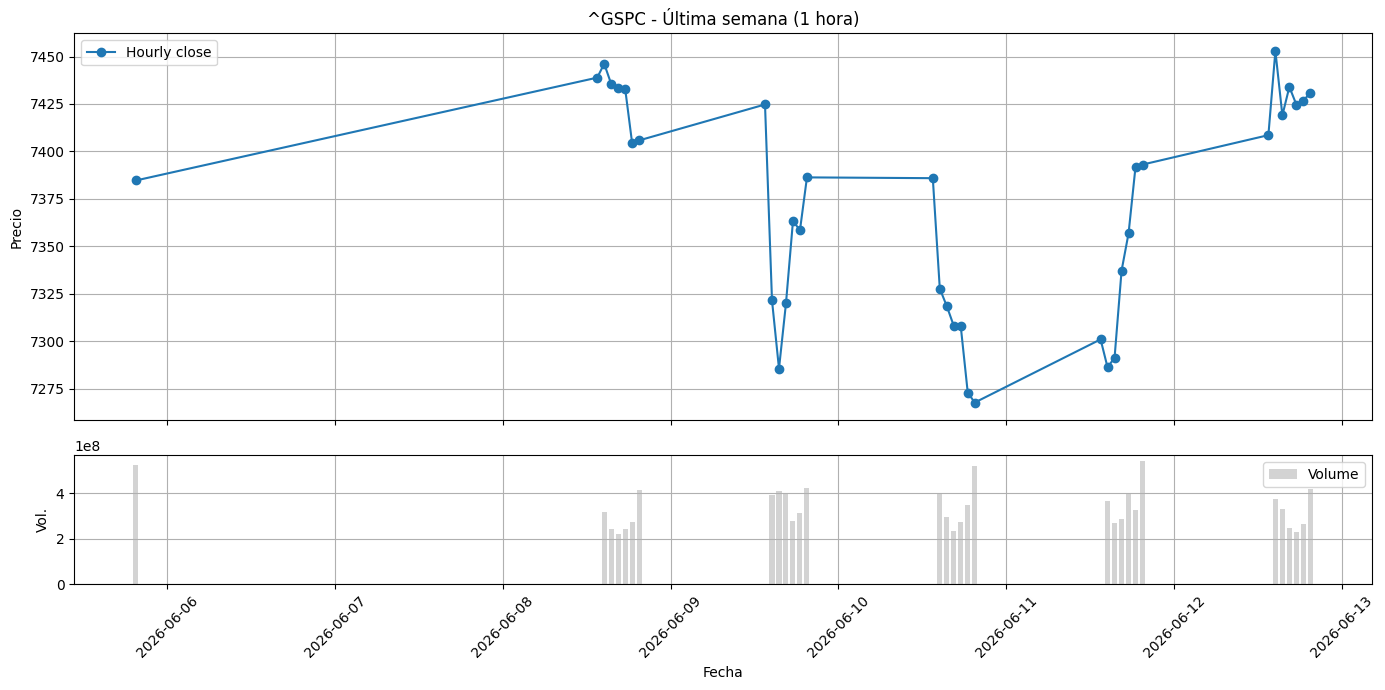

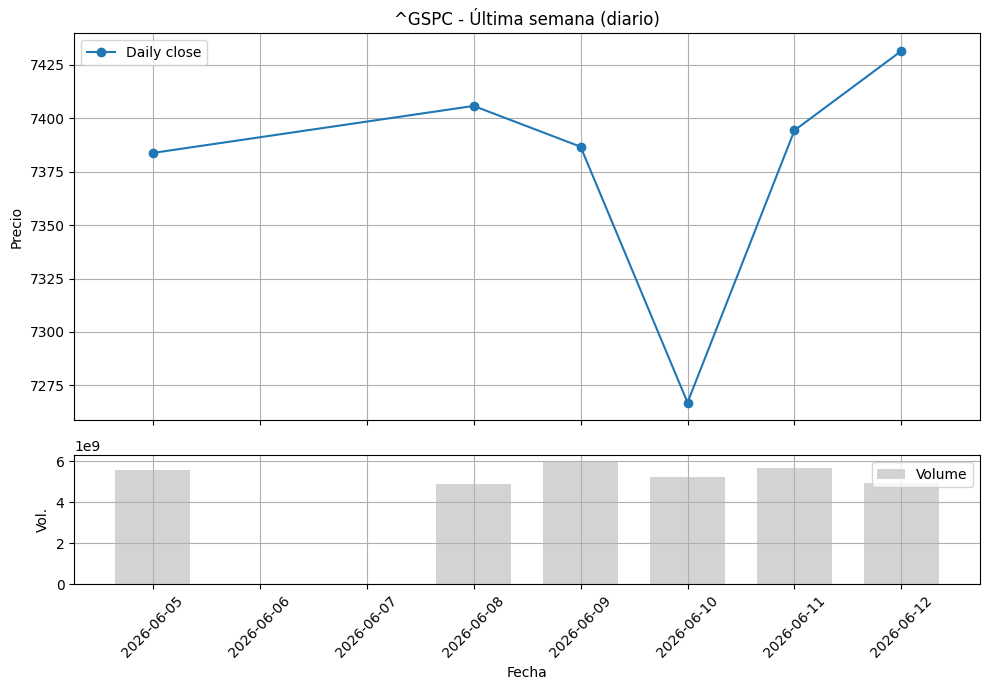

In [26]:

ticker = "^GSPC"  # Cambia aquí el activo que quieras

hourly = dataset[ticker]["hourly"].copy()
daily = dataset[ticker]["daily"].copy()

# Asegurarnos de que datetime es datetime
hourly["datetime"] = pd.to_datetime(hourly["datetime"])
daily["datetime"] = pd.to_datetime(daily["datetime"])

# Última semana disponible
hourly_last_week = hourly[
    hourly["datetime"] >= hourly["datetime"].max() - pd.Timedelta(days=7)
]

daily_last_week = daily[
    daily["datetime"] >= daily["datetime"].max() - pd.Timedelta(days=7)
]

# =========================
# Gráfico horario
# =========================

fig, (ax_price, ax_volume) = plt.subplots(
    2,
    1,
    figsize=(14, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

# Precio
ax_price.plot(
    hourly_last_week["datetime"],
    hourly_last_week["close"],
    marker="o",
    label="Hourly close",
)

ax_price.set_title(f"{ticker} - Última semana (1 hora)")
ax_price.set_ylabel("Precio")
ax_price.legend()
ax_price.grid(True)

# Volumen
ax_volume.bar(
    hourly_last_week["datetime"],
    hourly_last_week["volume"],
    color="lightgrey",
    width=0.03,  # ancho aproximado para barras horarias
    label="Volume",
)

ax_volume.set_xlabel("Fecha")
ax_volume.set_ylabel("Vol.")
ax_volume.legend()
ax_volume.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# =========================
# Gráfico diario
# =========================

fig, (ax_price, ax_volume) = plt.subplots(
    2,
    1,
    figsize=(10, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

# Precio
ax_price.plot(
    daily_last_week["datetime"],
    daily_last_week["close"],
    marker="o",
    label="Daily close",
)

ax_price.set_title(f"{ticker} - Última semana (diario)")
ax_price.set_ylabel("Precio")
ax_price.legend()
ax_price.grid(True)

# Volumen
ax_volume.bar(
    daily_last_week["datetime"],
    daily_last_week["volume"],
    color="lightgrey",
    width=0.7,  # ancho aproximado para barras diarias
    label="Volume",
)

ax_volume.set_xlabel("Fecha")
ax_volume.set_ylabel("Vol.")
ax_volume.legend()
ax_volume.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

¿Qué horas hay en el futuro y en el sp500?

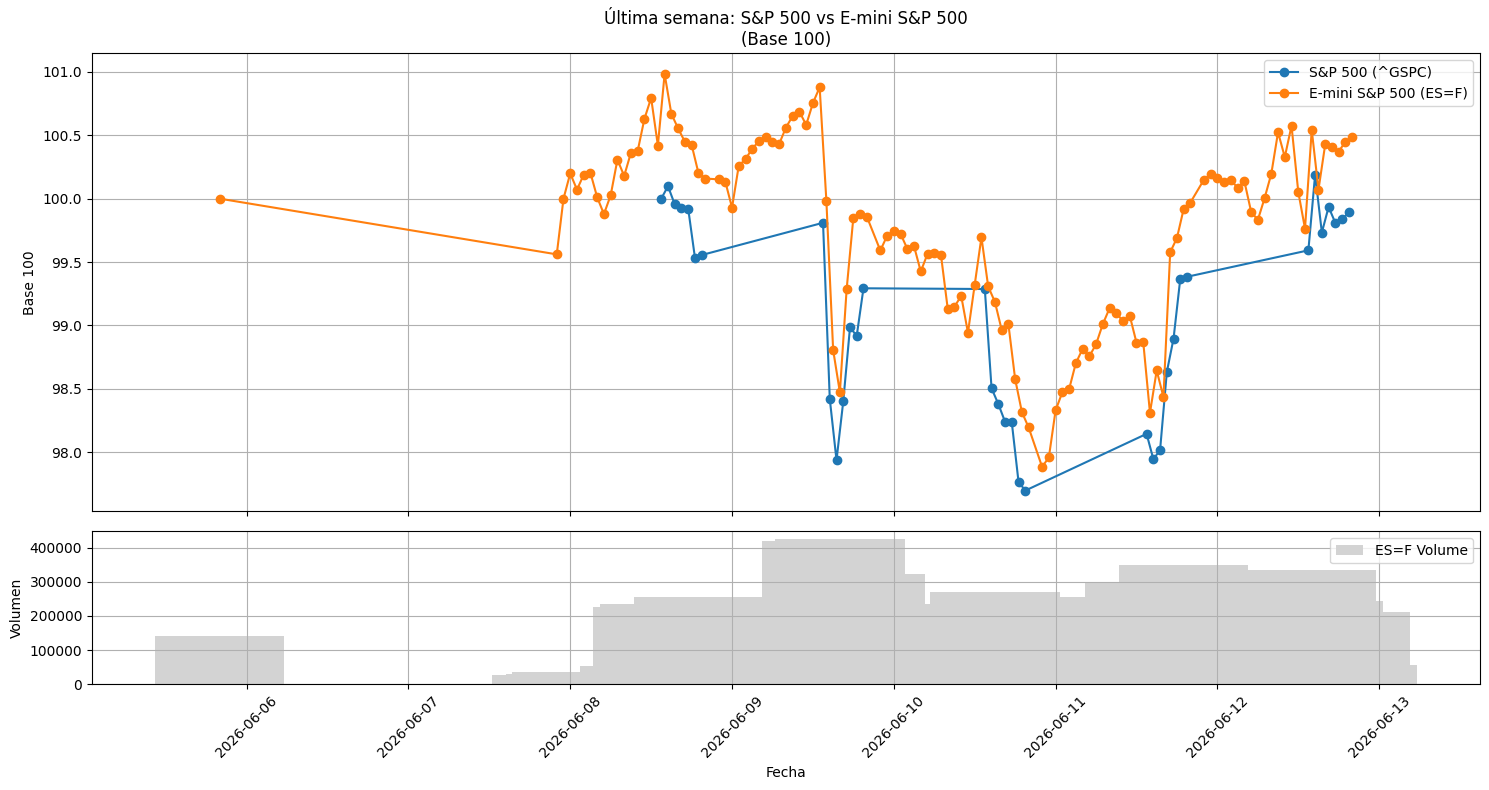

In [ ]:

# Activos a comparar
ticker_spx = "^GSPC"
ticker_es = "ES=F"

# Copias
spx = dataset[ticker_spx]["hourly"].copy()
es = dataset[ticker_es]["hourly"].copy()

# Fechas
spx["datetime"] = pd.to_datetime(spx["datetime"])
es["datetime"] = pd.to_datetime(es["datetime"])

# Última semana
fecha_limite = max(
    spx["datetime"].max(),
    es["datetime"].max(),
) - pd.Timedelta(days=7)

spx = spx[spx["datetime"] >= fecha_limite]
es = es[es["datetime"] >= fecha_limite]

# =========================
# Normalizar a base 100
# =========================

spx["close_base100"] = (
    spx["close"] / spx["close"].iloc[0] * 100
)

es["close_base100"] = (
    es["close"] / es["close"].iloc[0] * 100
)

# =========================
# Gráfico
# =========================

fig, (ax_price, ax_volume) = plt.subplots(
    2,
    1,
    figsize=(15, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

# Precios normalizados
ax_price.plot(
    spx["datetime"],
    spx["close_base100"],
    marker="o",
    label="S&P 500 (^GSPC)",
)

ax_price.plot(
    es["datetime"],
    es["close_base100"],
    marker="o",
    label="E-mini S&P 500 (ES=F)",
)

ax_price.set_title(
    "Última semana: S&P 500 vs E-mini S&P 500\n(Base 100)"
)
ax_price.set_ylabel("Base 100")
ax_price.legend()
ax_price.grid(True)

# Volumen del futuro (el del índice suele ser 0)
ax_volume.bar(
    es["datetime"],
    es["volume"],
    color="lightgrey",
    label="ES=F Volume",
)

ax_volume.set_ylabel("Volumen")
ax_volume.set_xlabel("Fecha")
ax_volume.legend()
ax_volume.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

¿Qué horas hay en general?

La idea sería responder a preguntas como:

- ¿Cuántas barras tiene cada activo al día?
- ¿A qué horas suele cotizar?
- ¿Qué activos tienen huecos?
- ¿Cuáles están vivos cuando abre el SP500?
- ¿Cuáles cotizan prácticamente 24 horas?

### 1. Número de observaciones por hora del día

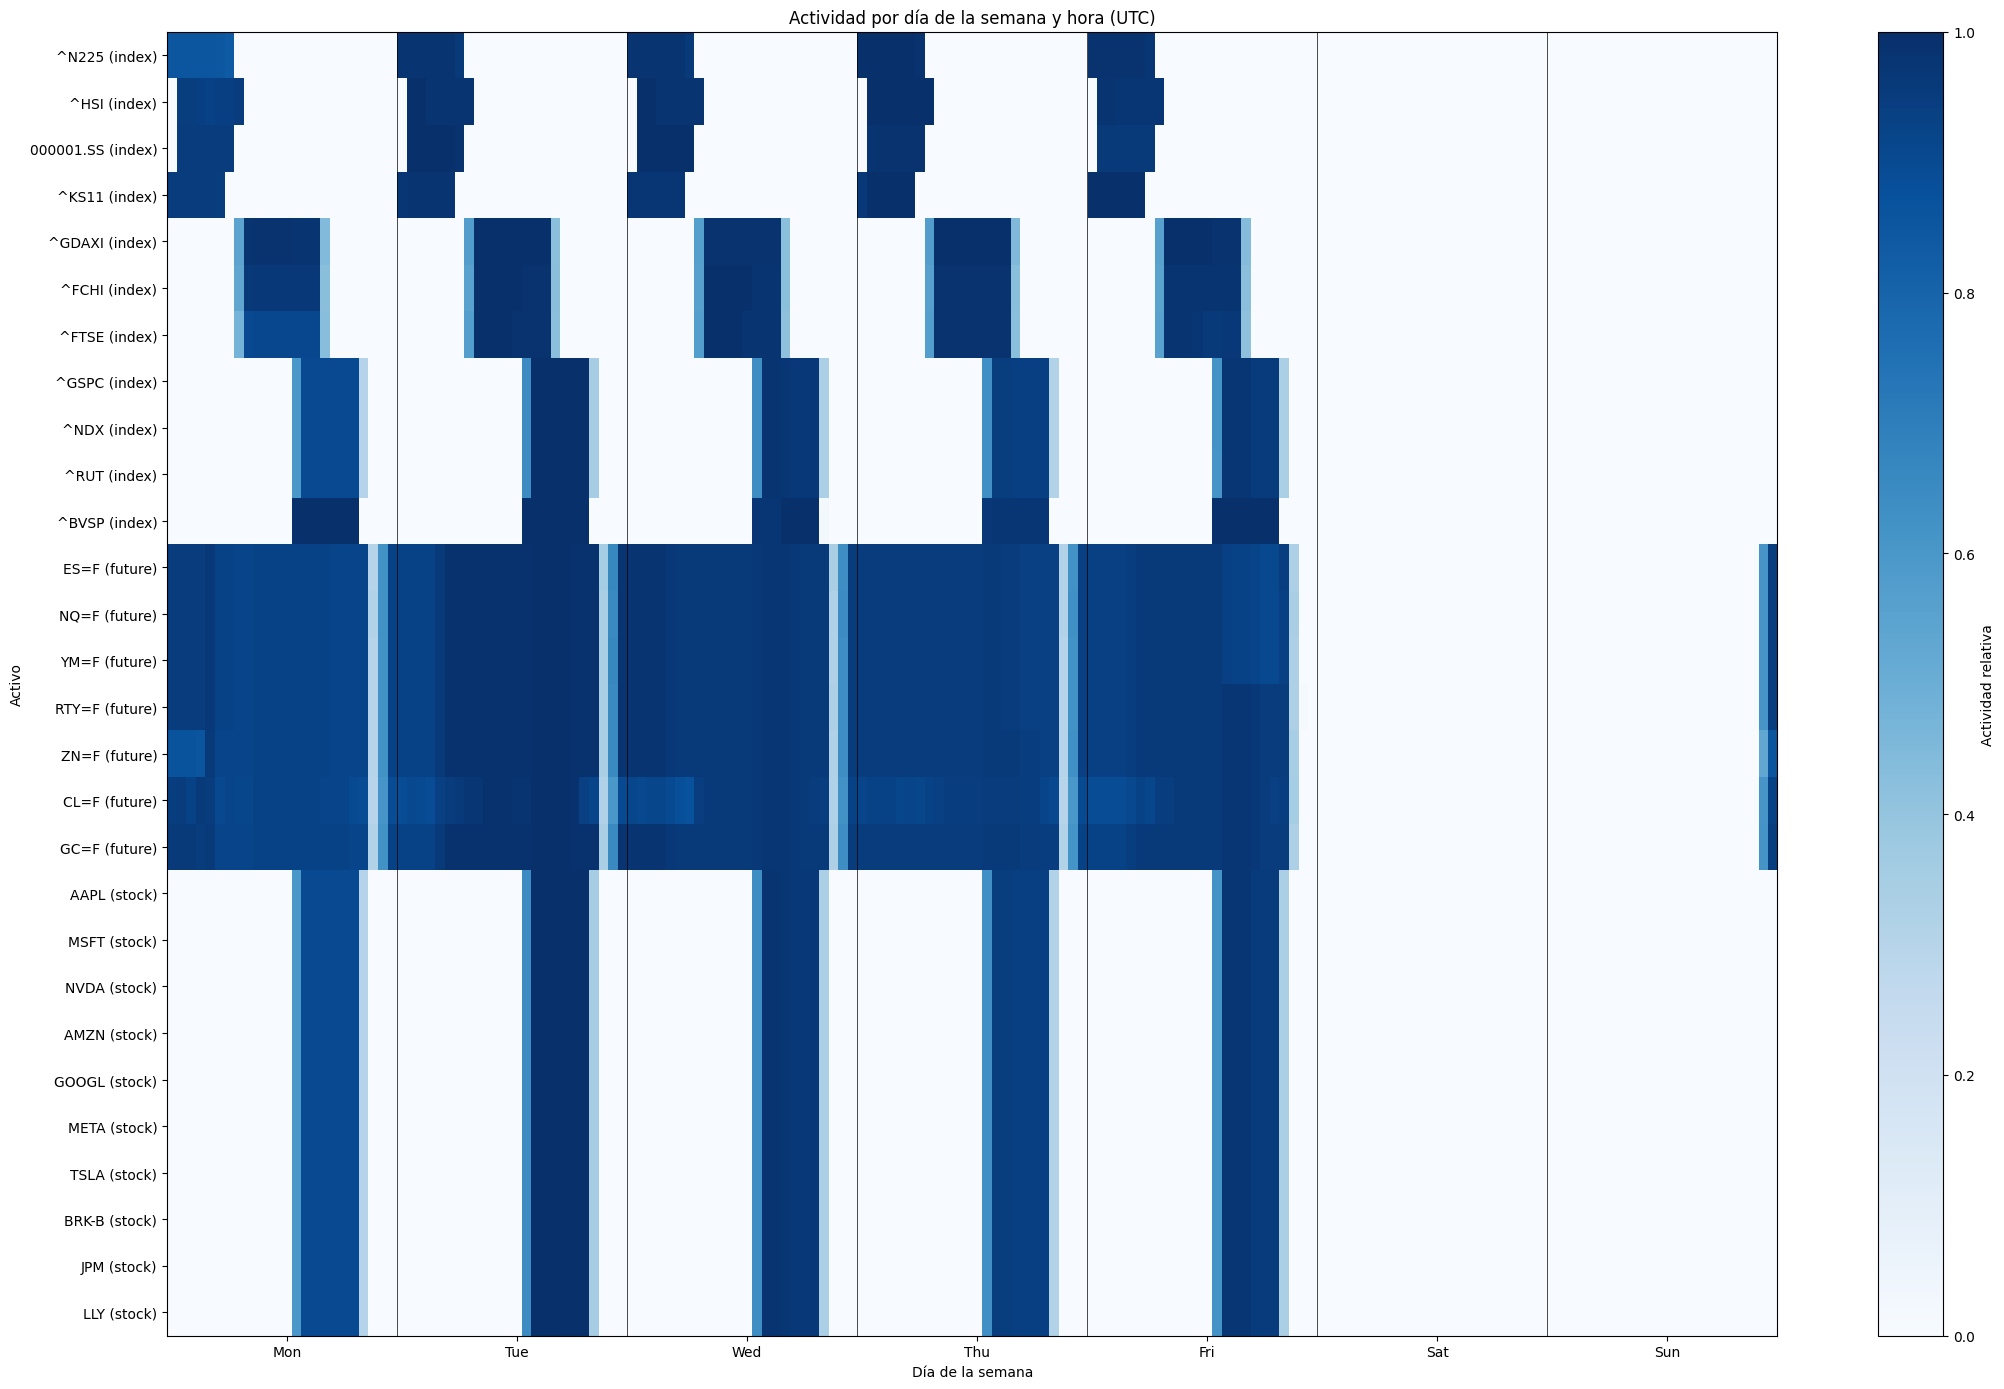

In [31]:


day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

heatmap = []
labels = []

for ticker, data in dataset.items():

    hourly = data["hourly"].copy()

    if hourly.empty:
        continue

    hourly["datetime"] = pd.to_datetime(hourly["datetime"])

    hourly["weekday"] = hourly["datetime"].dt.dayofweek
    hourly["hour"] = hourly["datetime"].dt.hour

    # Matriz 7 días × 24 horas
    counts = (
        hourly
        .groupby(["weekday", "hour"])
        .size()
        .unstack(fill_value=0)
        .reindex(index=range(7), columns=range(24), fill_value=0)
    )

    # Convertimos a un vector de longitud 168
    values = counts.values.flatten()

    # Normalizamos por activo
    if values.max() > 0:
        values = values / values.max()

    heatmap.append(values)

    labels.append(
        f"{ticker} ({data['metadata']['type']})"
    )

heatmap = np.array(heatmap)

plt.figure(figsize=(22, len(labels) * 0.5))

im = plt.imshow(
    heatmap,
    aspect="auto",
    cmap="Blues",
)

# Separadores entre días
for x in range(24, 168, 24):
    plt.axvline(x - 0.5, color="black", linewidth=0.5)

# Etiquetas cada día
xticks = [12 + 24 * i for i in range(7)]

plt.xticks(
    xticks,
    day_names,
)

plt.yticks(
    range(len(labels)),
    labels,
)

plt.title(
    "Actividad por día de la semana y hora (UTC)"
)

plt.xlabel("Día de la semana")
plt.ylabel("Activo")

cbar = plt.colorbar(im)
cbar.set_label("Actividad relativa")

plt.tight_layout()
plt.show()